In [1]:
import pandas as pd
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [2]:
df["mainroad"] = df["mainroad"].map({"yes":1,"no":0})
df["guestroom"] = df["guestroom"].map({"yes":1,"no":0})
df["basement"] = df["basement"].map({"yes":1,"no":0})
df["hotwaterheating"] = df["hotwaterheating"].map({"yes":1,"no":0})
df["airconditioning"] = df["airconditioning"].map({"yes":1,"no":0})
df["prefarea"] = df["prefarea"].map({"yes":1,"no":0})
df["furnishingstatus"] = df["furnishingstatus"].map({"unfurnished":0,"furnished":1,"semi-furnished":2})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,2
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


In [3]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [4]:
x = df.drop("price",axis=1)
y = df["price"]

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [7]:
print(y_pred)

[5261760.         7278320.         3753750.         4465090.
 3777585.         3542350.         5062260.         5130160.
 2542330.         2851289.         9988609.4        3363407.5
 3032353.33333333 3497200.         3642065.         3866240.
 3396330.         4838400.         3626000.         3968755.
 5493880.         5919900.         3066000.         3639580.
 4740400.         6628300.         3063620.         4519550.
 6365730.         3289580.         5767090.         3192000.
 6716990.         4301850.         2985675.         6325830.
 4839030.         3644130.         3095680.         4149040.
 4166470.         2838115.         7409920.         4207980.
 4028710.         4415250.         7251300.         4107565.
 2983400.         3036320.         8076185.6        2606730.
 4022900.         4502190.         3324825.         2832144.
 6934760.         3034570.         5133800.         3114703.33333333
 4061470.         3528000.         4563230.         4580520.
 3852275.      

In [9]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = (mse**0.5)
print("mean_absolute_error: ",mae)
print("mean_sqaured_error: ",mse)
print("r2_score: ",r2)
print("root_mean_squared_error: ",rmse)


mean_absolute_error:  1020691.0645259939
mean_sqaured_error:  1946928655165.67
r2_score:  0.614818162519784
root_mean_squared_error:  1395323.8531486767


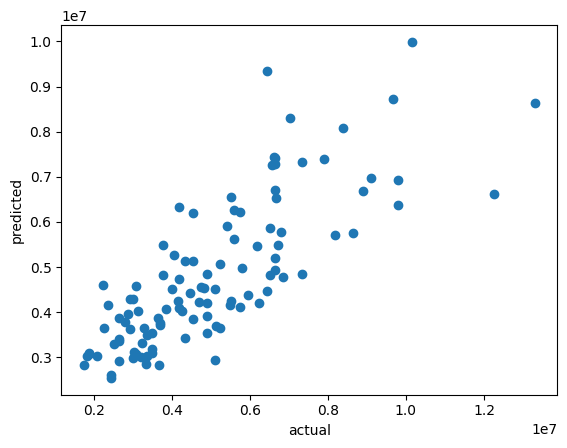

In [10]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("predicted")
plt.show()

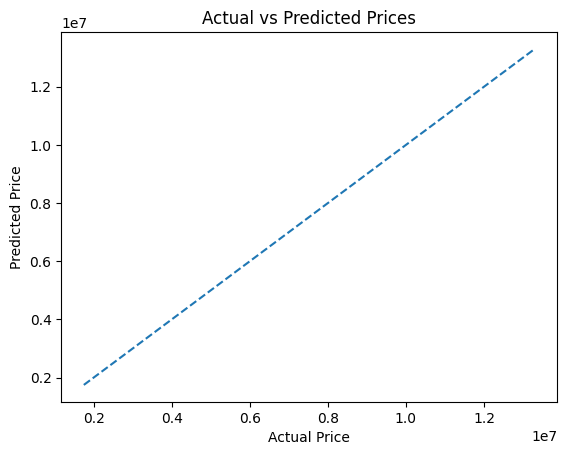

In [13]:
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()


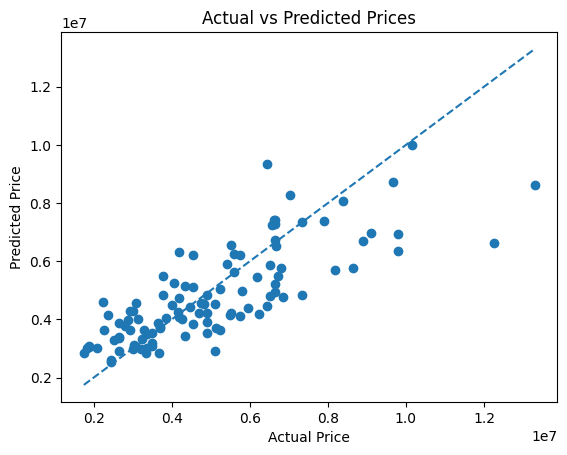

In [14]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [15]:
residuals = y_test - y_pred
print(residuals.head())

316   -1201760.0
77     -628320.0
360     -43750.0
90     1974910.0
493    -977585.0
Name: price, dtype: float64


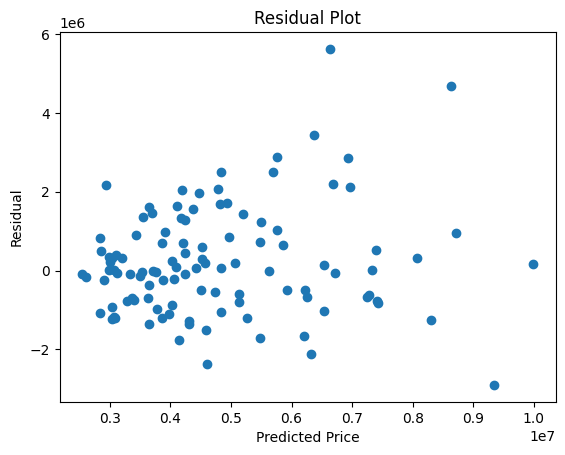

In [16]:
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [17]:
absolute_errors = abs(residuals)
print(absolute_errors.nlargest(5))

2     5621700.0
0     4668993.0
10    3434270.0
89    2899750.0
22    2887360.0
Name: price, dtype: float64


In [18]:
print("Day 21 completed successfully!")

Day 21 completed successfully!
